# House Prices 대면적 이상치 제거 조합 전수검색

`GrLivArea > 4,000`인 사전 지정 후보 `Id=524, 692, 1183, 1299`의 모든 부분집합을 고정 검증 조건에서 비교한다.

## tl;dr

- 4개 후보의 **16개 제거 조합을 Ridge와 수동 PyTorch에서 모두 실행**했다.
- seed 42 Ridge 최상위는 `exclude_1299`: CV **0.127303**.
- seed 42 PyTorch 최상위는 `exclude_1299`: CV **0.128635**.
- PyTorch 우승 조합은 3개 split seed 중 **3개**에서 `keep_all`보다 좋았고 평균 delta는 **-0.001656**이다. Ridge는 **3/3**, 평균 delta **-0.003951**다.
- 현재 결정은 **provisional_best**, 잠정 제외 Id는 **[1299]**다.
- 조합 선택과 점수 계산에 같은 1,460행을 재사용했으므로 결과는 `Share with caveats`이며 Kaggle 점수는 미검증이다.

## Context & Methods

### Key Assumptions

- 후보 집합은 분석 전에 정한 대면적 4건으로 고정한다. OOF 잔차를 본 뒤 후보를 계속 추가하지 않는다.
- 4건의 16개 부분집합(0·1·2·3·4건 제외)을 모두 평가한다.
- 모든 validation 행은 유지하고, 지정된 `Id`만 각 fold의 학습 부분에서 제외한다.
- 1차 비교는 all-feature Ridge, 최종 판단의 주 모델은 수동 PyTorch `TabularMLP`다.
- seed 42 탐색의 PyTorch 최상위 조합을 split seed 2026·3407에서도 `keep_all`과 재비교한다.
- 조합 선택과 성능 추정에 같은 데이터가 반복 사용되므로 결과는 잠정 정책이며 Kaggle 점수로 간주하지 않는다.

In [1]:
from __future__ import annotations

import hashlib
import itertools
import json
import os
import sys
import time
from dataclasses import asdict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from scipy import sparse
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

ROOT = Path.cwd()
if not (ROOT / "data" / "train.csv").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str((ROOT / "by_ai").resolve()))

from src.data import build_linear_preprocessor, load_house_prices
from src.experiments import EXPERIMENT_COLUMNS, evaluate_sklearn_cv, make_folds, rmse_log
from src.model import NNConfig
from src.training import predict_log, train_with_early_stopping

RUN_ID = "20260719T122912Z"
SEARCH_SEED = 42
SENSITIVITY_SEEDS = [42, 2026, 3407]
CANDIDATE_IDS = (524, 692, 1183, 1299)
TRAIN_PATH = ROOT / "data" / "train.csv"
FINAL_MLP_METRICS_PATH = ROOT / "by_ai" / "artifacts" / "metrics" / "AI-20260719T041029Z-NN-ARCH-256-128-64.json"
METRICS_PATH = ROOT / "reports" / "outlier_subset_metrics.json"
OOF_PATH = ROOT / "reports" / "outlier_subset_oof_predictions.csv"
DETAIL_EXPERIMENTS_PATH = ROOT / "reports" / "outlier_subset_experiments.csv"

train = load_house_prices(TRAIN_PATH)
X = train.drop(columns=["SalePrice"])
y_log = np.log1p(pd.to_numeric(train["SalePrice"], errors="raise").to_numpy(float))
final_mlp_payload = json.loads(FINAL_MLP_METRICS_PATH.read_text(encoding="utf-8"))
preprocess_config = final_mlp_payload["preprocessing"]
nn_config_payload = dict(final_mlp_payload["config"])
nn_config_payload["hidden_dims"] = tuple(nn_config_payload["hidden_dims"])
nn_config = NNConfig(**nn_config_payload)
candidate_subsets = [
    tuple(combination)
    for size in range(len(CANDIDATE_IDS) + 1)
    for combination in itertools.combinations(CANDIDATE_IDS, size)
]

torch.set_num_threads(min(4, os.cpu_count() or 1))

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def records(frame: pd.DataFrame) -> list[dict]:
    return json.loads(frame.to_json(orient="records"))

def variant_label(excluded_ids: tuple[int, ...] | list[int]) -> str:
    values = tuple(int(value) for value in excluded_ids)
    return "keep_all" if not values else "exclude_" + "_".join(map(str, values))

def dense_float32(values) -> np.ndarray:
    if sparse.issparse(values):
        values = values.toarray()
    result = np.asarray(values, dtype=np.float32)
    if result.ndim != 2 or not np.isfinite(result).all():
        raise ValueError("preprocessed matrix must be finite and 2D")
    return result

assert train.shape == (1460, 81)
assert train["Id"].is_unique
assert len(candidate_subsets) == 16 and len(set(candidate_subsets)) == 16
assert len(nn_config.hidden_dims) >= 2
print(f"run={RUN_ID}; train={train.shape}; subsets={len(candidate_subsets)}; seeds={SENSITIVITY_SEEDS}")

run=20260719T122912Z; train=(1460, 81); subsets=16; seeds=[42, 2026, 3407]


## Data

In [2]:
candidate_rows = train.loc[
    train["Id"].isin(CANDIDATE_IDS),
    [
        "Id", "GrLivArea", "SalePrice", "OverallQual", "Neighborhood",
        "SaleCondition", "YearBuilt", "YearRemodAdd", "YrSold",
    ],
].copy()
candidate_rows["price_per_living_sf"] = candidate_rows["SalePrice"] / candidate_rows["GrLivArea"]
source_summary = {
    "train_rows": len(train),
    "train_columns": train.shape[1],
    "train_sha256": sha256(TRAIN_PATH),
    "candidate_ids": list(CANDIDATE_IDS),
    "candidate_subsets": len(candidate_subsets),
    "final_mlp_reference": final_mlp_payload["experiment_id"],
    "final_mlp_reference_cv_mean": final_mlp_payload["cv_mean"],
}
display(candidate_rows.sort_values("Id"))
display(pd.DataFrame([source_summary]))

,Id,GrLivArea,SalePrice,OverallQual,Neighborhood,SaleCondition,YearBuilt,YearRemodAdd,YrSold,price_per_living_sf
523,524,4676,184750,10,Edwards,Partial,2007,2008,2007,39.510265
691,692,4316,755000,10,NoRidge,Normal,1994,1995,2007,174.930491
1182,1183,4476,745000,10,NoRidge,Abnorml,1996,1996,2007,166.443253
1298,1299,5642,160000,10,Edwards,Partial,2008,2008,2008,28.358738


,train_rows,train_columns,train_sha256,candidate_ids,candidate_subsets,final_mlp_reference,final_mlp_reference_cv_mean
0,1460,81,1e18addf81e5e4d347cc17ee6075bbe4a42b7fa26b9e5b...,"[524, 692, 1183, 1299]",16,AI-20260719T041029Z-NN-ARCH-256-128-64,0.132135


## Results

### 1. Ridge: 16개 제거 조합 전수검색

In [3]:
def ridge_factory() -> Pipeline:
    return Pipeline(
        [
            (
                "preprocess",
                build_linear_preprocessor(
                    preprocess_config["groups"],
                    preprocess_config["rare_min_count"],
                    preprocess_config["log_skew"],
                ),
            ),
            ("model", Ridge(alpha=15.0, solver="lsqr")),
        ]
    )

def evaluate_ridge_subset(excluded_ids: tuple[int, ...], split_seed: int):
    folds = make_folds(len(train), n_splits=5, seed=split_seed)
    result = evaluate_sklearn_cv(
        ridge_factory,
        X,
        y_log,
        folds,
        exclude_from_training=train["Id"].isin(excluded_ids).to_numpy(),
    )
    return {
        "model": "Ridge",
        "variant": variant_label(excluded_ids),
        "excluded_ids": list(excluded_ids),
        "excluded_count": len(excluded_ids),
        "split_seed": split_seed,
        "cv_mean": result.cv_mean,
        "cv_std": result.cv_std,
        "oof_rmsle": result.oof_score,
        "fold_scores": result.fold_scores,
        "train_sizes": result.train_sizes,
        "validation_sizes": result.validation_sizes,
        "oof_predictions": result.oof_predictions,
        "duration_seconds": None,
        "artifact_id": "",
        "fold_metadata": [],
    }

ridge_grid_runs = []
ridge_oof_by_variant = {}
for excluded_ids in candidate_subsets:
    started = time.perf_counter()
    run = evaluate_ridge_subset(excluded_ids, SEARCH_SEED)
    run["duration_seconds"] = time.perf_counter() - started
    ridge_grid_runs.append(run)
    ridge_oof_by_variant[run["variant"]] = run.pop("oof_predictions")

ridge_grid = pd.DataFrame(ridge_grid_runs)
ridge_reference_mean = float(ridge_grid.loc[ridge_grid["excluded_count"].eq(0), "cv_mean"].iloc[0])
ridge_grid["delta_vs_keep_all"] = ridge_grid["cv_mean"] - ridge_reference_mean
ridge_grid = ridge_grid.sort_values(["cv_mean", "excluded_count", "variant"]).reset_index(drop=True)
ridge_grid["rank"] = np.arange(1, len(ridge_grid) + 1)
display(ridge_grid[["rank", "variant", "excluded_ids", "cv_mean", "cv_std", "oof_rmsle", "delta_vs_keep_all", "fold_scores"]])

,rank,variant,excluded_ids,cv_mean,cv_std,oof_rmsle,delta_vs_keep_all,fold_scores
0,1,exclude_1299,[1299],0.127303,0.032423,0.130565,-0.004607,"[0.12747630965404874, 0.10550448932774235, 0.1..."
1,2,exclude_524_1299,"[524, 1299]",0.127306,0.032501,0.130583,-0.004604,"[0.12796239824932543, 0.10545043139071682, 0.1..."
2,3,exclude_524_692_1183_1299,"[524, 692, 1183, 1299]",0.128310,0.035183,0.132113,-0.003600,"[0.12794247754124569, 0.1054970326177327, 0.18..."
3,4,exclude_692_1183_1299,"[692, 1183, 1299]",0.128426,0.035113,0.132210,-0.003485,"[0.1280389301484302, 0.10558421707639101, 0.18..."
4,5,exclude_524_1183_1299,"[524, 1183, 1299]",0.128561,0.035773,0.132483,-0.003349,"[0.12794247754124569, 0.10545043139071682, 0.1..."
5,6,exclude_1183_1299,"[1183, 1299]",0.128676,0.035703,0.132579,-0.003234,"[0.1280389301484302, 0.10550448932774235, 0.19..."
6,7,exclude_524_692_1299,"[524, 692, 1299]",0.128841,0.036123,0.132830,-0.003069,"[0.12796239824932543, 0.1054970326177327, 0.19..."
7,8,exclude_692_1299,"[692, 1299]",0.128883,0.036027,0.132850,-0.003027,"[0.12747630965404874, 0.10558421707639101, 0.1..."
8,9,keep_all,[],0.131910,0.029603,0.134541,0.000000,"[0.13078440035988154, 0.11668101992889157, 0.1..."
9,10,exclude_524,[524],0.131919,0.029598,0.134549,0.000009,"[0.1307823454333688, 0.11665806546929179, 0.18..."


### 2. 수동 PyTorch: 같은 16개 조합 전수검색

In [4]:
def evaluate_mlp_subset(
    excluded_ids: tuple[int, ...],
    split_seed: int,
    phase: str,
):
    folds = make_folds(len(train), n_splits=5, seed=split_seed)
    excluded_mask = train["Id"].isin(excluded_ids).to_numpy()
    label = variant_label(excluded_ids)
    artifact_id = f"OUTLIER-COMBO-{RUN_ID}-{phase}-SEED{split_seed}-{label}"
    oof = np.full(len(train), np.nan, dtype=float)
    fold_scores = []
    train_sizes = []
    validation_sizes = []
    fold_metadata = []
    started = time.perf_counter()

    for fold_number, (train_idx, valid_idx) in enumerate(folds, start=1):
        retained_train_idx = train_idx[~excluded_mask[train_idx]]
        preprocessor = build_linear_preprocessor(
            preprocess_config["groups"],
            preprocess_config["rare_min_count"],
            preprocess_config["log_skew"],
        )
        train_matrix = dense_float32(preprocessor.fit_transform(X.iloc[retained_train_idx]))
        valid_matrix = dense_float32(preprocessor.transform(X.iloc[valid_idx]))
        checkpoint_path = (
            ROOT / "by_ai" / "artifacts" / "checkpoints" / artifact_id / f"fold_{fold_number}_best.pt"
        )
        epoch_log_path = (
            ROOT / "by_ai" / "artifacts" / "logs" / artifact_id / f"fold_{fold_number}_epochs.csv"
        )
        model, training = train_with_early_stopping(
            train_matrix,
            y_log[retained_train_idx],
            valid_matrix,
            y_log[valid_idx],
            nn_config,
            checkpoint_path,
            epoch_log_path,
            seed=split_seed + fold_number,
            device="cpu",
            experiment_id=artifact_id,
        )
        valid_prediction = predict_log(
            model,
            valid_matrix,
            training.target_mean,
            training.target_std,
            "cpu",
        )
        score = rmse_log(y_log[valid_idx], valid_prediction)
        if not np.isclose(score, training.best_val_rmsle, atol=1e-5):
            raise AssertionError("restored checkpoint score mismatch")
        oof[valid_idx] = valid_prediction
        fold_scores.append(score)
        train_sizes.append(len(retained_train_idx))
        validation_sizes.append(len(valid_idx))
        fold_metadata.append(
            {
                "fold": fold_number,
                "input_dim": train_matrix.shape[1],
                "best_epoch": training.best_epoch,
                "stopped_epoch": training.stopped_epoch,
                "checkpoint_path": str(checkpoint_path.relative_to(ROOT)),
                "epoch_log_path": str(epoch_log_path.relative_to(ROOT)),
                "restored_rmsle": score,
            }
        )

    if np.isnan(oof).any():
        raise RuntimeError("MLP OOF predictions are incomplete")
    return {
        "model": "manual PyTorch TabularMLP",
        "variant": label,
        "excluded_ids": list(excluded_ids),
        "excluded_count": len(excluded_ids),
        "split_seed": split_seed,
        "cv_mean": float(np.mean(fold_scores)),
        "cv_std": float(np.std(fold_scores, ddof=1)),
        "oof_rmsle": rmse_log(y_log, oof),
        "fold_scores": fold_scores,
        "train_sizes": train_sizes,
        "validation_sizes": validation_sizes,
        "oof_predictions": oof,
        "duration_seconds": time.perf_counter() - started,
        "artifact_id": artifact_id,
        "fold_metadata": fold_metadata,
    }

mlp_grid_runs = []
mlp_oof_by_variant = {}
for excluded_ids in candidate_subsets:
    run = evaluate_mlp_subset(excluded_ids, SEARCH_SEED, "GRID")
    mlp_grid_runs.append(run)
    mlp_oof_by_variant[run["variant"]] = run.pop("oof_predictions")
    print(f"{run['variant']}: {run['cv_mean']:.6f} ± {run['cv_std']:.6f}")

mlp_grid = pd.DataFrame(mlp_grid_runs)
mlp_reference_mean = float(mlp_grid.loc[mlp_grid["excluded_count"].eq(0), "cv_mean"].iloc[0])
mlp_grid["delta_vs_keep_all"] = mlp_grid["cv_mean"] - mlp_reference_mean
mlp_grid = mlp_grid.sort_values(["cv_mean", "excluded_count", "variant"]).reset_index(drop=True)
mlp_grid["rank"] = np.arange(1, len(mlp_grid) + 1)

assert np.isclose(mlp_reference_mean, final_mlp_payload["cv_mean"], atol=1e-6)
display(mlp_grid[["rank", "variant", "excluded_ids", "cv_mean", "cv_std", "oof_rmsle", "delta_vs_keep_all", "fold_scores"]])

keep_all: 0.132135 ± 0.027368


exclude_524: 0.133280 ± 0.026776


exclude_692: 0.134708 ± 0.033630


exclude_1183: 0.132864 ± 0.029891


exclude_1299: 0.128635 ± 0.028547


...

exclude_524_692_1299: 0.133984 ± 0.033172


exclude_524_1183_1299: 0.131208 ± 0.030208


exclude_692_1183_1299: 0.128924 ± 0.024145


exclude_524_692_1183_1299: 0.130084 ± 0.023504


,rank,variant,excluded_ids,cv_mean,cv_std,oof_rmsle,delta_vs_keep_all,fold_scores
0,1,exclude_1299,[1299],0.128635,0.028547,0.131145,-0.003499,"[0.12490481537305019, 0.11706297296248731, 0.1..."
1,2,exclude_692_1183_1299,"[692, 1183, 1299]",0.128924,0.024145,0.130720,-0.003211,"[0.1265709200552891, 0.12151572317983923, 0.17..."
2,3,exclude_524_1299,"[524, 1299]",0.128980,0.029153,0.131589,-0.003155,"[0.1290021487570526, 0.11365184532645889, 0.17..."
3,4,exclude_524_692_1183_1299,"[524, 692, 1183, 1299]",0.130084,0.023504,0.131772,-0.002050,"[0.12870344460536487, 0.11895068169440241, 0.1..."
4,5,exclude_1183_1299,"[1183, 1299]",0.130624,0.030277,0.133402,-0.001511,"[0.1265709200552891, 0.11706297296248731, 0.18..."
5,6,exclude_524_692_1183,"[524, 692, 1183]",0.131151,0.023478,0.132821,-0.000984,"[0.12748999216725643, 0.12959985981189645, 0.1..."
6,7,exclude_524_1183_1299,"[524, 1183, 1299]",0.131208,0.030208,0.133961,-0.000926,"[0.12870344460536487, 0.11365184532645889, 0.1..."
7,8,keep_all,[],0.132135,0.027368,0.134383,0.000000,"[0.12504436565020147, 0.13030371343349842, 0.1..."
8,9,exclude_1183,[1183],0.132864,0.029891,0.135527,0.000729,"[0.12747940880983202, 0.13030371343349842, 0.1..."
9,10,exclude_692_1299,"[692, 1299]",0.133174,0.033433,0.136490,0.001039,"[0.12490481537305019, 0.12151572317983923, 0.1..."


### 3. 두 모델 순위와 seed 42 우승 조합

,variant,excluded_ids,excluded_count,ridge_rank,ridge_cv_mean,ridge_delta,mlp_rank,mlp_cv_mean,mlp_delta,mean_rank
0,exclude_1299,[1299],1,1,0.127303,-0.004607,1,0.128635,-0.003499,1.0
1,exclude_692_1183_1299,"[692, 1183, 1299]",3,4,0.128426,-0.003485,2,0.128924,-0.003211,3.0
2,exclude_524_1299,"[524, 1299]",2,2,0.127306,-0.004604,3,0.128980,-0.003155,2.5
3,exclude_524_692_1183_1299,"[524, 692, 1183, 1299]",4,3,0.128310,-0.003600,4,0.130084,-0.002050,3.5
4,exclude_1183_1299,"[1183, 1299]",2,6,0.128676,-0.003234,5,0.130624,-0.001511,5.5
5,exclude_524_692_1183,"[524, 692, 1183]",3,13,0.136399,0.004489,6,0.131151,-0.000984,9.5
6,exclude_524_1183_1299,"[524, 1183, 1299]",3,5,0.128561,-0.003349,7,0.131208,-0.000926,6.0
7,keep_all,[],0,9,0.131910,0.000000,8,0.132135,0.000000,8.5
8,exclude_1183,[1183],1,15,0.136745,0.004835,9,0.132864,0.000729,12.0
9,exclude_692_1299,"[692, 1299]",2,8,0.128883,-0.003027,10,0.133174,0.001039,9.0


/var/folders/1l/f_wt2jbd1fgf4fhrgb7z_yrm0000gn/T/ipykernel_32319/3233359306.py:33: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1l/f_wt2jbd1fgf4fhrgb7z_yrm0000gn/T/ipykernel_32319/3233359306.py:33: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1l/f_wt2jbd1fgf4fhrgb7z_yrm0000gn/T/ipykernel_32319/3233359306.py:33: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1l/f_wt2jbd1fgf4fhrgb7z_yrm0000gn/T/ipykernel_32319/3233359306.py:33: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1l/f_wt2jbd1fgf4fhrgb7z_yrm0000gn/T/ipykernel_32319/3233359306.py:33: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1l/f_wt2jbd1fgf4fhrgb7z_yrm0000gn/T/ipy

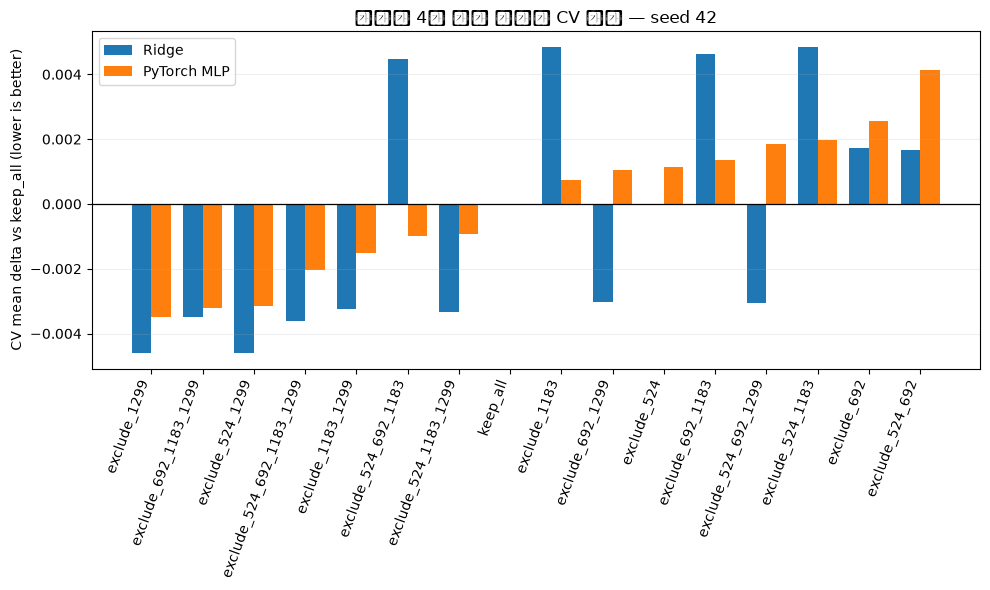

In [5]:
combined_ranking = ridge_grid[
    ["variant", "excluded_ids", "excluded_count", "rank", "cv_mean", "delta_vs_keep_all"]
].rename(
    columns={"rank": "ridge_rank", "cv_mean": "ridge_cv_mean", "delta_vs_keep_all": "ridge_delta"}
).merge(
    mlp_grid[["variant", "rank", "cv_mean", "delta_vs_keep_all"]].rename(
        columns={"rank": "mlp_rank", "cv_mean": "mlp_cv_mean", "delta_vs_keep_all": "mlp_delta"}
    ),
    on="variant",
    validate="one_to_one",
)
combined_ranking["mean_rank"] = (combined_ranking["ridge_rank"] + combined_ranking["mlp_rank"]) / 2
combined_ranking = combined_ranking.sort_values(["mlp_rank", "ridge_rank"]).reset_index(drop=True)

ridge_best = ridge_grid.iloc[0].to_dict()
mlp_best = mlp_grid.iloc[0].to_dict()
selected_subset = tuple(int(value) for value in mlp_best["excluded_ids"])
selected_variant = variant_label(selected_subset)
display(combined_ranking)

fig, ax = plt.subplots(figsize=(10, 6))
plot_frame = combined_ranking.sort_values("mlp_delta")
positions = np.arange(len(plot_frame))
width = 0.38
ax.bar(positions - width / 2, plot_frame["ridge_delta"], width, label="Ridge")
ax.bar(positions + width / 2, plot_frame["mlp_delta"], width, label="PyTorch MLP")
ax.axhline(0, color="black", linewidth=0.9)
ax.set_xticks(positions, plot_frame["variant"], rotation=70, ha="right")
ax.set_ylabel("CV mean delta vs keep_all (lower is better)")
ax.set_title("대면적 4건 제거 조합별 CV 변화 — seed 42")
ax.legend()
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### 4. 우승 조합의 추가 split-seed 민감도

In [6]:
sensitivity_runs = []
sensitivity_oof = {}

def grid_record(frame: pd.DataFrame, variant: str) -> dict:
    return frame.loc[frame["variant"].eq(variant)].iloc[0].to_dict()

for model_name, grid_frame, oof_lookup in [
    ("Ridge", ridge_grid, ridge_oof_by_variant),
    ("manual PyTorch TabularMLP", mlp_grid, mlp_oof_by_variant),
]:
    for role, subset in [("keep_all", ()), ("selected", selected_subset)]:
        label = variant_label(subset)
        reused = grid_record(grid_frame, label)
        reused.update({"comparison_role": role, "phase": "SEED_SENSITIVITY", "reused_grid_run": True})
        sensitivity_runs.append(reused)
        sensitivity_oof[(model_name, SEARCH_SEED, role)] = oof_lookup[label]

for split_seed in SENSITIVITY_SEEDS[1:]:
    for role, subset in [("keep_all", ()), ("selected", selected_subset)]:
        ridge_run = evaluate_ridge_subset(subset, split_seed)
        ridge_run.update({"comparison_role": role, "phase": "SEED_SENSITIVITY", "reused_grid_run": False})
        sensitivity_oof[("Ridge", split_seed, role)] = ridge_run.pop("oof_predictions")
        sensitivity_runs.append(ridge_run)

        mlp_run = evaluate_mlp_subset(subset, split_seed, "SENS")
        mlp_run.update({"comparison_role": role, "phase": "SEED_SENSITIVITY", "reused_grid_run": False})
        sensitivity_oof[("manual PyTorch TabularMLP", split_seed, role)] = mlp_run.pop("oof_predictions")
        sensitivity_runs.append(mlp_run)
        print(f"seed={split_seed} {role}: Ridge={ridge_run['cv_mean']:.6f}, MLP={mlp_run['cv_mean']:.6f}")

sensitivity_detail = pd.DataFrame(sensitivity_runs)
sensitivity_summary_rows = []
for model_name in ["Ridge", "manual PyTorch TabularMLP"]:
    model_runs = sensitivity_detail[sensitivity_detail["model"].eq(model_name)]
    for split_seed in SENSITIVITY_SEEDS:
        seed_runs = model_runs[model_runs["split_seed"].eq(split_seed)].set_index("comparison_role")
        keep_score = float(seed_runs.loc["keep_all", "cv_mean"])
        selected_score = float(seed_runs.loc["selected", "cv_mean"])
        sensitivity_summary_rows.append(
            {
                "model": model_name,
                "split_seed": split_seed,
                "keep_all_cv_mean": keep_score,
                "selected_cv_mean": selected_score,
                "delta_selected_minus_keep": selected_score - keep_score,
                "selected_improved": selected_score < keep_score,
            }
        )
sensitivity_summary = pd.DataFrame(sensitivity_summary_rows)
display(sensitivity_summary)

model_seed_summary = (
    sensitivity_summary.groupby("model")
    .agg(
        mean_keep_all=("keep_all_cv_mean", "mean"),
        mean_selected=("selected_cv_mean", "mean"),
        mean_delta=("delta_selected_minus_keep", "mean"),
        improved_seed_count=("selected_improved", "sum"),
    )
    .reset_index()
)
display(model_seed_summary)

seed=2026 keep_all: Ridge=0.133566, MLP=0.135078


seed=2026 selected: Ridge=0.129114, MLP=0.133768


seed=3407 keep_all: Ridge=0.131695, MLP=0.129805


seed=3407 selected: Ridge=0.128900, MLP=0.129646


,model,split_seed,keep_all_cv_mean,selected_cv_mean,delta_selected_minus_keep,selected_improved
0,Ridge,42,0.131910,0.127303,-0.004607,True
1,Ridge,2026,0.133566,0.129114,-0.004452,True
2,Ridge,3407,0.131695,0.128900,-0.002795,True
3,manual PyTorch TabularMLP,42,0.132135,0.128635,-0.003499,True
4,manual PyTorch TabularMLP,2026,0.135078,0.133768,-0.001310,True
5,manual PyTorch TabularMLP,3407,0.129805,0.129646,-0.000158,True


,model,mean_keep_all,mean_selected,mean_delta,improved_seed_count
0,Ridge,0.132390,0.128439,-0.003951,3
1,manual PyTorch TabularMLP,0.132339,0.130683,-0.001656,3


## Takeaways

In [7]:
mlp_seed_check = model_seed_summary.set_index("model").loc["manual PyTorch TabularMLP"]
ridge_seed_check = model_seed_summary.set_index("model").loc["Ridge"]
robust_candidate = bool(
    mlp_seed_check["mean_delta"] < 0
    and mlp_seed_check["improved_seed_count"] >= 2
    and ridge_seed_check["mean_delta"] < 0
    and ridge_seed_check["improved_seed_count"] >= 2
)
recommended_subset = selected_subset if robust_candidate else ()
recommendation_status = "provisional_best" if robust_candidate else "retain_all"

display(
    Markdown(
        f'''
        - seed 42 Ridge 최상위: **{ridge_best['variant']}**, CV **{ridge_best['cv_mean']:.6f}** (keep_all 대비 {ridge_best['delta_vs_keep_all']:+.6f}).
        - seed 42 PyTorch 최상위: **{mlp_best['variant']}**, CV **{mlp_best['cv_mean']:.6f}** (keep_all 대비 {mlp_best['delta_vs_keep_all']:+.6f}).
        - 선택 조합 `{list(selected_subset)}`은 PyTorch에서 3개 split seed 중 **{int(mlp_seed_check['improved_seed_count'])}개** 개선, 평균 delta **{mlp_seed_check['mean_delta']:+.6f}**이다.
        - 현재 정책: **{recommendation_status}**, 잠정 제외 Id는 **{list(recommended_subset)}**다.
        - 16개 조합을 같은 데이터에서 비교했으므로 이 점수는 선택 편향 가능성이 있으며 Kaggle leaderboard 점수는 미검증이다.
        '''
    )
)


        - seed 42 Ridge 최상위: **exclude_1299**, CV **0.127303** (keep_all 대비 -0.004607).
        - seed 42 PyTorch 최상위: **exclude_1299**, CV **0.128635** (keep_all 대비 -0.003499).
        - 선택 조합 `[1299]`은 PyTorch에서 3개 split seed 중 **3개** 개선, 평균 delta **-0.001656**이다.
        - 현재 정책: **provisional_best**, 잠정 제외 Id는 **[1299]**다.
        - 16개 조합을 같은 데이터에서 비교했으므로 이 점수는 선택 편향 가능성이 있으며 Kaggle leaderboard 점수는 미검증이다.
        

### Artifacts & Validation

In [8]:
oof_artifact = pd.DataFrame({"Id": train["Id"], "actual_log1p": y_log})
for variant, predictions in ridge_oof_by_variant.items():
    oof_artifact[f"ridge_seed42__{variant}"] = predictions
for variant, predictions in mlp_oof_by_variant.items():
    oof_artifact[f"mlp_seed42__{variant}"] = predictions
for (model_name, split_seed, role), predictions in sensitivity_oof.items():
    if split_seed == SEARCH_SEED:
        continue
    prefix = "ridge" if model_name == "Ridge" else "mlp"
    oof_artifact[f"{prefix}_seed{split_seed}__{role}"] = predictions
oof_artifact.to_csv(OOF_PATH, index=False)

generated_at = datetime.now(timezone.utc).isoformat()
metrics = {
    "run_id": RUN_ID,
    "generated_at_utc": generated_at,
    "status": "share_with_caveats",
    "source_summary": source_summary,
    "method": {
        "candidate_ids": list(CANDIDATE_IDS),
        "candidate_subsets": len(candidate_subsets),
        "search_seed": SEARCH_SEED,
        "sensitivity_seeds": SENSITIVITY_SEEDS,
        "validation": "KFold(n_splits=5, shuffle=True); validation rows retained; exclusions only from fold training",
        "metric": "RMSE on log1p(SalePrice), equivalent to RMSLE",
        "primary_model": "manual PyTorch TabularMLP",
    },
    "ridge_grid": records(ridge_grid),
    "mlp_grid": records(mlp_grid),
    "combined_ranking": records(combined_ranking),
    "sensitivity_detail": records(sensitivity_detail),
    "sensitivity_summary": records(sensitivity_summary),
    "model_seed_summary": records(model_seed_summary),
    "decision": {
        "ridge_best_variant": ridge_best["variant"],
        "ridge_best_excluded_ids": ridge_best["excluded_ids"],
        "ridge_best_cv_mean": ridge_best["cv_mean"],
        "mlp_best_variant": mlp_best["variant"],
        "mlp_best_excluded_ids": mlp_best["excluded_ids"],
        "mlp_best_cv_mean": mlp_best["cv_mean"],
        "seed42_selected_subset": list(selected_subset),
        "robust_candidate": robust_candidate,
        "recommendation_status": recommendation_status,
        "recommended_excluded_ids": list(recommended_subset),
        "selection_caveat": "Subset selection and scoring reuse the same 1460 rows; additional seeds change folds but are not independent data.",
    },
    "artifacts": {
        "notebook": str((ROOT / "notebooks" / "house_prices_outlier_subset_search.ipynb").relative_to(ROOT)),
        "metrics": str(METRICS_PATH.relative_to(ROOT)),
        "oof_predictions": str(OOF_PATH.relative_to(ROOT)),
        "detail_experiments": str(DETAIL_EXPERIMENTS_PATH.relative_to(ROOT)),
    },
}
METRICS_PATH.write_text(json.dumps(metrics, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

def blank_experiment(**updates):
    row = {column: "" for column in EXPERIMENT_COLUMNS}
    row.update(updates)
    return row

experiment_rows = []
data_version = f"train.csv sha256={source_summary['train_sha256']}"
split_strategy = "KFold(n_splits=5,shuffle=True,random_state=42)"
common_artifact = "notebooks/house_prices_outlier_subset_search.ipynb; reports/outlier_subset_metrics.json; reports/outlier_subset_oof_predictions.csv"

for _, row in ridge_grid.iterrows():
    experiment_rows.append(
        blank_experiment(
            experiment_id=f"OUTLIER-COMBO-{RUN_ID}-RIDGE-{row['variant']}",
            datetime=generated_at,
            objective="Exhaustive training-only exclusion subset search over pre-specified GrLivArea>4000 rows",
            data_version=data_version,
            split_strategy=split_strategy,
            folds=5,
            seed=SEARCH_SEED,
            metric="RMSLE / RMSE on log1p target",
            preprocessing="Fold-fit all-feature preprocessing: structural absence; median; scaling; one-hot; rare_min_count=10; skew log1p",
            features="All candidate House Prices feature groups; Id excluded; all validation rows retained",
            model="sklearn Ridge",
            loss="squared error on log1p target",
            hyperparameters=json.dumps({"alpha": 15.0, "solver": "lsqr", "excluded_training_ids": row["excluded_ids"]}, ensure_ascii=False),
            cv_mean=row["cv_mean"],
            cv_std=row["cv_std"],
            artifact_path=common_artifact,
            result="grid_best" if row["rank"] == 1 else "completed",
            interpretation=f"Rank {int(row['rank'])}/16; delta vs keep_all {row['delta_vs_keep_all']:+.6f}; OOF RMSLE {row['oof_rmsle']:.6f}",
            next_action="Use only as supporting evidence for the manual PyTorch result.",
        )
    )

architecture = final_mlp_payload["architecture"]
for _, row in mlp_grid.iterrows():
    fold_metadata = row["fold_metadata"]
    experiment_rows.append(
        blank_experiment(
            experiment_id=f"OUTLIER-COMBO-{RUN_ID}-MLP-{row['variant']}",
            datetime=generated_at,
            objective="Exhaustive training-only exclusion subset search with the final manual PyTorch architecture",
            data_version=data_version,
            split_strategy=split_strategy,
            folds=5,
            seed=SEARCH_SEED,
            metric="RMSLE / RMSE on log1p target",
            preprocessing="Fold-fit all-feature preprocessing and fold-train target standardization",
            features="All candidate House Prices feature groups; Id excluded; all validation rows retained",
            model="manual PyTorch TabularMLP",
            architecture=architecture,
            optimizer="AdamW",
            loss="SmoothL1Loss(beta=0.5) on fold-standardized log1p target",
            learning_rate=nn_config.learning_rate,
            batch_size=nn_config.batch_size,
            max_epochs=nn_config.max_epochs,
            patience=nn_config.patience,
            best_epoch="folds=" + "|".join(str(item["best_epoch"]) for item in fold_metadata),
            hyperparameters=json.dumps({**asdict(nn_config), "excluded_training_ids": row["excluded_ids"], "fold_seeds": [43, 44, 45, 46, 47]}, ensure_ascii=False),
            cv_mean=row["cv_mean"],
            cv_std=row["cv_std"],
            checkpoint_path=f"by_ai/artifacts/checkpoints/{row['artifact_id']}",
            artifact_path=common_artifact + f"; by_ai/artifacts/logs/{row['artifact_id']}",
            result="grid_best" if row["rank"] == 1 else "completed",
            interpretation=f"Rank {int(row['rank'])}/16; delta vs keep_all {row['delta_vs_keep_all']:+.6f}; restored best checkpoints; OOF RMSLE {row['oof_rmsle']:.6f}",
            next_action="Confirm the seed-42 winner across additional fold seeds before adopting.",
        )
    )

for _, row in sensitivity_detail[~sensitivity_detail["reused_grid_run"]].iterrows():
    is_mlp = row["model"] == "manual PyTorch TabularMLP"
    experiment_id = f"OUTLIER-COMBO-{RUN_ID}-SENS-{int(row['split_seed'])}-{'MLP' if is_mlp else 'RIDGE'}-{row['comparison_role']}"
    experiment_rows.append(
        blank_experiment(
            experiment_id=experiment_id,
            datetime=generated_at,
            objective="Additional split-seed sensitivity for the seed-42 winning outlier subset versus keep_all",
            data_version=data_version,
            split_strategy=f"KFold(n_splits=5,shuffle=True,random_state={int(row['split_seed'])})",
            folds=5,
            seed=int(row["split_seed"]),
            metric="RMSLE / RMSE on log1p target",
            preprocessing="Fold-fit all-feature preprocessing" + (" and fold-train target standardization" if is_mlp else ""),
            features=f"All candidate groups; role={row['comparison_role']}; excluded_training_ids={row['excluded_ids']}",
            model=row["model"],
            architecture=architecture if is_mlp else "",
            optimizer="AdamW" if is_mlp else "",
            loss="SmoothL1Loss(beta=0.5) on fold-standardized log1p target" if is_mlp else "squared error on log1p target",
            learning_rate=nn_config.learning_rate if is_mlp else "",
            batch_size=nn_config.batch_size if is_mlp else "",
            max_epochs=nn_config.max_epochs if is_mlp else "",
            patience=nn_config.patience if is_mlp else "",
            best_epoch=("folds=" + "|".join(str(item["best_epoch"]) for item in row["fold_metadata"])) if is_mlp else "",
            hyperparameters=json.dumps({"excluded_training_ids": row["excluded_ids"], "split_seed": int(row["split_seed"])}, ensure_ascii=False),
            cv_mean=row["cv_mean"],
            cv_std=row["cv_std"],
            checkpoint_path=f"by_ai/artifacts/checkpoints/{row['artifact_id']}" if is_mlp else "",
            artifact_path=common_artifact + (f"; by_ai/artifacts/logs/{row['artifact_id']}" if is_mlp else ""),
            result="seed_sensitivity",
            interpretation=f"role={row['comparison_role']}; OOF RMSLE {row['oof_rmsle']:.6f}",
            next_action="Compare paired keep_all and selected scores for the same split seed.",
        )
    )

experiment_frame = pd.DataFrame(experiment_rows, columns=EXPERIMENT_COLUMNS)
experiment_frame.to_csv(DETAIL_EXPERIMENTS_PATH, index=False)

assert len(ridge_grid) == 16 and len(mlp_grid) == 16
assert len(experiment_frame) == 40
assert experiment_frame["experiment_id"].is_unique
assert np.isfinite(oof_artifact.drop(columns=["Id"]).to_numpy(dtype=float)).all()
assert oof_artifact["Id"].equals(train["Id"])
assert METRICS_PATH.exists() and OOF_PATH.exists() and DETAIL_EXPERIMENTS_PATH.exists()
print(f"검증 완료: metrics={METRICS_PATH.relative_to(ROOT)}, experiments={len(experiment_frame)}")

검증 완료: metrics=reports/outlier_subset_metrics.json, experiments=40
